In [1]:
# Import required libraries for data manipulation and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for a clean, professional look
plt.style.use('seaborn-v0_8-darkgrid')

In [3]:
# Load the micro and macro datasets
# Assuming this notebook is inside the 'notebooks' folder and data is in 'data'
df_daily = pd.read_csv('/content/digital_habits_march2026.csv')
df_monthly = pd.read_csv('/content/parami_digital_summary_3years.csv')

# Convert date columns to datetime objects for time-series analysis
df_daily['date'] = pd.to_datetime(df_daily['date'])

In [4]:
# Check the first few rows of the daily behavioral data
display(df_daily.head())

# Check for any missing values
print("\nMissing values in daily dataset:")
print(df_daily.isnull().sum())

,date,day_of_week,total_screen_time_hours,productive_screen_time_hours,social_media_hours,entertainment_hours,study_hours,productivity_score,mood_score,sleep_hours,...,late_night_usage,internship_meeting_day,assignment_deadline_nearby,stress_level,caffeine_intake_cups,breaks_taken,weekday_type,free_time_hours,class_hours,gaming_or_streaming_hours
0,2026-03-01,Sunday,5.6,2.3,2.0,0.7,2.2,7,7,7.4,...,No,No,No,4,1,2,Weekend,12.0,0.0,0.4
1,2026-03-02,Monday,7.2,3.7,2.1,1.0,3.5,7,5,7.3,...,No,No,No,5,2,4,Weekday,8.6,6.0,0.8
2,2026-03-03,Tuesday,6.4,1.0,3.6,1.5,1.0,7,7,7.2,...,No,No,No,3,2,4,Weekday,12.0,1.6,0.5
3,2026-03-04,Wednesday,8.5,4.5,1.9,1.7,3.3,7,4,7.8,...,No,Yes,No,4,2,5,Weekday,8.3,5.3,1.1
4,2026-03-05,Thursday,5.6,1.8,2.9,0.5,1.9,4,5,7.6,...,Yes,No,No,1,2,2,Weekday,12.0,1.0,0.5



Missing values in daily dataset:
date                            0
day_of_week                     0
total_screen_time_hours         1
productive_screen_time_hours    2
social_media_hours              0
entertainment_hours             0
study_hours                     0
productivity_score              0
mood_score                      0
sleep_hours                     0
notifications_count             0
focus_score                     1
physical_activity_minutes       0
most_used_app_category          0
primary_device_used             0
late_night_usage                0
internship_meeting_day          0
assignment_deadline_nearby      0
stress_level                    0
caffeine_intake_cups            0
breaks_taken                    0
weekday_type                    0
free_time_hours                 0
class_hours                     0
gaming_or_streaming_hours       0
dtype: int64


In [5]:
# Fill missing productive screen time with the median to avoid skewing data
median_productive = df_daily['productive_screen_time_hours'].median()
df_daily['productive_screen_time_hours'] = df_daily['productive_screen_time_hours'].fillna(median_productive)

# Verify missing values are handled
print("Missing values after cleaning:", df_daily['productive_screen_time_hours'].isnull().sum())

Missing values after cleaning: 0


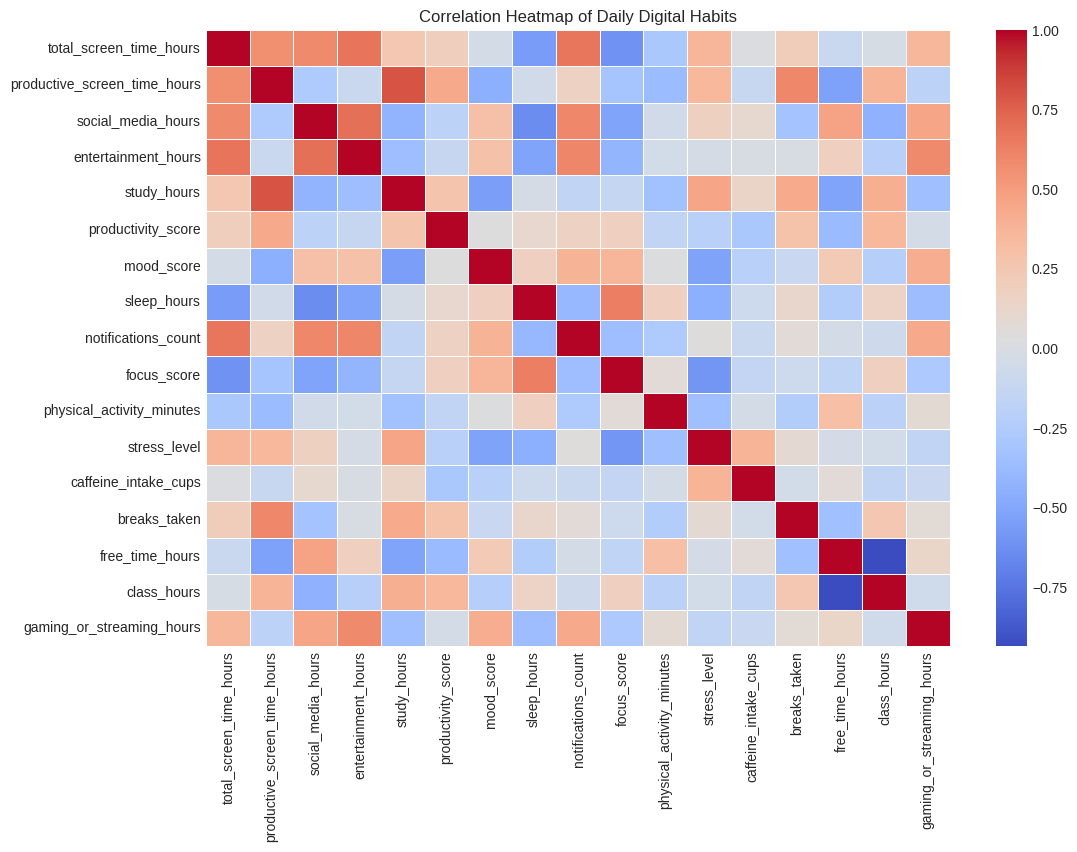

In [6]:
# Select only numerical columns to find correlations
numerical_cols = df_daily.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df_daily[numerical_cols].corr()

# Plot a heatmap to visualize what behaviors are linked
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Daily Digital Habits')
plt.show()

# Insight: Look for strong positive/negative correlations with 'productivity_score'

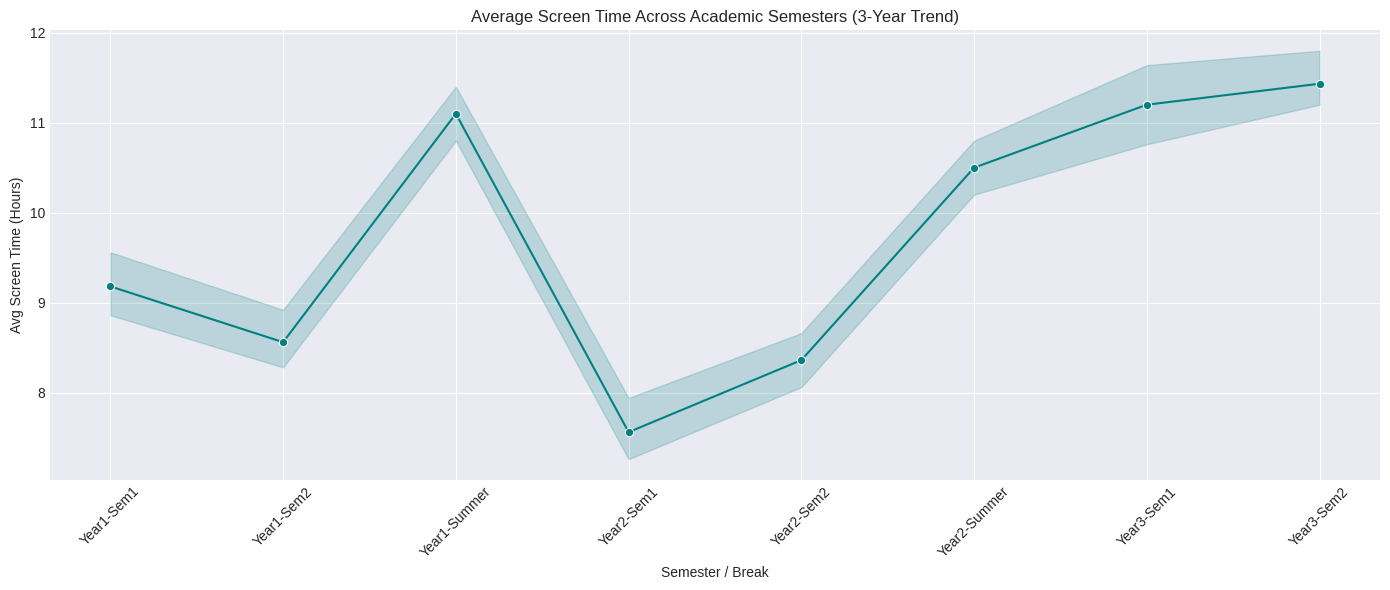

In [7]:
# Visualize long-term screen time trends across different academic periods
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=df_monthly,
    x='semester',
    y='avg_screen_time_hours',
    marker='o',
    color='teal'
)
plt.xticks(rotation=45)
plt.title('Average Screen Time Across Academic Semesters (3-Year Trend)')
plt.ylabel('Avg Screen Time (Hours)')
plt.xlabel('Semester / Break')
plt.tight_layout()
plt.show()